In [17]:
# ======================================================================
# CELL 1- NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY & STATISTICAL ANALYSIS
# ======================================================================

import os
import joblib
import random
import warnings
import numpy as np
import pandas as pd

from pathlib import Path

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------
# SET RANDOM SEED FOR REPRODUCIBILITY
# ----------------------------------------------------------------------
RANDOM_SEEDS = [42, 123, 7]

# Primary project seed
RANDOM_STATE = RANDOM_SEEDS[0]

# Set primary random state
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ----------------------------------------------------------------------
# DISPLAY
# ----------------------------------------------------------------------
print("=" * 70)
print("NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY")
print("                & STATISTICAL ANALYSIS")
print("=" * 70)

print()
print("REPRODUCIBILITY CONFIGURATION")
print("-" * 70)
print(f"Random seeds:        {RANDOM_SEEDS}")
print(f"Primary random seed: {RANDOM_STATE}")

print()
print("✓ Required libraries imported")
print("✓ Random seeds configured")
print("✓ Primary random state set to 42")
print("✓ Notebook 11 initialized")

NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY
                & STATISTICAL ANALYSIS

REPRODUCIBILITY CONFIGURATION
----------------------------------------------------------------------
Random seeds:        [42, 123, 7]
Primary random seed: 42

✓ Required libraries imported
✓ Random seeds configured
✓ Primary random state set to 42
✓ Notebook 11 initialized


In [ ]:
# ======================================================================
# CELL 2- NOTEBOOK 11 — PROJECT PATHS & FINAL MODEL LOADING
# ======================================================================
#Cell 2 — Define project paths/directories
BASE_DIR = Path.cwd()
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIELD_DIR = DATA_DIR / "field"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT /"models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
REPORT_DIR = RESULTS_DIR / "reports"
# Create output directories
for folder in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# FINAL SP-XGBOOST ARTIFACTS
# ----------------------------------------------------------------------
SP_XGBOOST_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "sp_xgboost_binary.pkl"
)

SHAP_IMPORTANCE_PATH = os.path.join(
    RESULTS_DIR,
    "final_sp_xgboost_shap_importance.csv"
)

# ----------------------------------------------------------------------
# PATH VALIDATION
# ----------------------------------------------------------------------
print("=" * 70)
print("PROJECT PATH & ARTIFACT VALIDATION")
print("=" * 70)

print(f"Project directory: {PROJECT_ROOT}")
print(f"Processed data:    {PROCESSED_DIR}")
print(f"Models:            {MODELS_DIR}")
print(f"Results:           {RESULTS_DIR}")

assert os.path.isdir(PROJECT_ROOT), "Project directory not found"
assert os.path.isdir(PROCESSED_DIR), "Processed-data directory not found"
assert os.path.isdir(MODELS_DIR), "Model directory not found"
assert os.path.isdir(RESULTS_DIR), "Results directory not found"

print()
print("✓ All project directories validated")

# ----------------------------------------------------------------------
# FINAL SP-XGBOOST MODEL VALIDATION
# ----------------------------------------------------------------------
print()
print("=" * 70)
print("LOADING FINAL SP-XGBOOST MODEL")
print("=" * 70)

assert os.path.isfile(
    SP_XGBOOST_MODEL_PATH
), "Final SP-XGBoost model file not found"

sp_xgboost_model = joblib.load(SP_XGBOOST_MODEL_PATH)

print(f"Model file: {SP_XGBOOST_MODEL_PATH}")
print()
print("✓ Final SP-XGBoost model loaded successfully")
print("✓ Model was loaded without retraining")

PROJECT PATH & ARTIFACT VALIDATION
Project directory: ..
Processed data:    ..\data\processed
Models:            ..\models
Results:           ..\results

✓ All project directories validated

LOADING FINAL SP-XGBOOST MODEL
Model file: ..\models\sp_xgboost_binary.pkl

✓ Final SP-XGBoost model loaded successfully
✓ Model was loaded without retraining


In [19]:
# ======================================================================
# CELL 3 - NOTEBOOK 11 — FINAL FEATURE / DATA ALIGNMENT
# ======================================================================

print("=" * 70)
print("FINAL SP-XGBOOST FEATURE / DATA ALIGNMENT")
print("=" * 70)

# ----------------------------------------------------------------------
# LOCATE SHAP-PRUNED DATASETS
# ----------------------------------------------------------------------
TRAIN_SHAP_PATH = os.path.join(
    PROCESSED_DIR,
    "train_binary_shap.csv"
)

TEST_SHAP_PATH = os.path.join(
    PROCESSED_DIR,
    "test_binary_shap.csv"
)

assert os.path.isfile(TRAIN_SHAP_PATH), (
    "SHAP-pruned training dataset not found"
)

assert os.path.isfile(TEST_SHAP_PATH), (
    "SHAP-pruned testing dataset not found"
)

# ----------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------
train_shap = pd.read_csv(TRAIN_SHAP_PATH)
test_shap = pd.read_csv(TEST_SHAP_PATH)

print(f"Training dataset shape: {train_shap.shape}")
print(f"Testing dataset shape:  {test_shap.shape}")

# ----------------------------------------------------------------------
# TARGET
# ----------------------------------------------------------------------
BINARY_TARGET = "RISK_BINARY"

assert BINARY_TARGET in train_shap.columns
assert BINARY_TARGET in test_shap.columns

# ----------------------------------------------------------------------
# EXTRACT PREDICTORS
# ----------------------------------------------------------------------
X_train_final = train_shap.drop(columns=[BINARY_TARGET])
y_train_final = train_shap[BINARY_TARGET]

X_test_final = test_shap.drop(columns=[BINARY_TARGET])
y_test_final = test_shap[BINARY_TARGET]

# ----------------------------------------------------------------------
# BASIC VALIDATION
# ----------------------------------------------------------------------
print()
print("FINAL DATA MATRICES")
print("-" * 70)

print(f"X_train_final: {X_train_final.shape}")
print(f"y_train_final: {y_train_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")
print(f"y_test_final:  {y_test_final.shape}")

assert X_train_final.shape[0] == 468
assert X_test_final.shape[0] == 117

assert X_train_final.shape[1] == 49
assert X_test_final.shape[1] == 49

# ----------------------------------------------------------------------
# MODEL FEATURE ALIGNMENT
# ----------------------------------------------------------------------
print()
print("=" * 70)
print("MODEL FEATURE ALIGNMENT")
print("=" * 70)

# Retrieve feature names from the trained XGBoost model
model_features = list(sp_xgboost_model.get_booster().feature_names)

training_features = list(X_train_final.columns)
testing_features = list(X_test_final.columns)

print(f"Model predictors:    {len(model_features)}")
print(f"Training predictors: {len(training_features)}")
print(f"Testing predictors:  {len(testing_features)}")

# Exact feature-set validation
assert model_features == training_features, (
    "Model feature order does not match training feature order"
)

assert model_features == testing_features, (
    "Model feature order does not match testing feature order"
)

print()
print("✓ Model contains exactly 49 predictors")
print("✓ Training data contains exactly 49 predictors")
print("✓ Testing data contains exactly 49 predictors")
print("✓ Model / training feature order matches exactly")
print("✓ Model / testing feature order matches exactly")
print("✓ Final SP-XGBoost feature alignment validated")

# ----------------------------------------------------------------------
# TARGET VALIDATION
# ----------------------------------------------------------------------
print()
print("=" * 70)
print("BINARY TARGET VALIDATION")
print("=" * 70)

print("Training target distribution:")
print(y_train_final.value_counts().sort_index())

print()
print("Testing target distribution:")
print(y_test_final.value_counts().sort_index())

assert set(y_train_final.unique()).issubset({0, 1})
assert set(y_test_final.unique()).issubset({0, 1})

print()
print("✓ Binary target confirmed")
print("✓ Classes 0 and 1 confirmed")
print("✓ Training observations: 468")
print("✓ Testing observations: 117")
print("✓ 49 final SP-XGBoost predictors confirmed")

FINAL SP-XGBOOST FEATURE / DATA ALIGNMENT
Training dataset shape: (468, 50)
Testing dataset shape:  (117, 50)

FINAL DATA MATRICES
----------------------------------------------------------------------
X_train_final: (468, 49)
y_train_final: (468,)
X_test_final:  (117, 49)
y_test_final:  (117,)

MODEL FEATURE ALIGNMENT
Model predictors:    49
Training predictors: 49
Testing predictors:  49

✓ Model contains exactly 49 predictors
✓ Training data contains exactly 49 predictors
✓ Testing data contains exactly 49 predictors
✓ Model / training feature order matches exactly
✓ Model / testing feature order matches exactly
✓ Final SP-XGBoost feature alignment validated

BINARY TARGET VALIDATION
Training target distribution:
RISK_BINARY
0    244
1    224
Name: count, dtype: int64

Testing target distribution:
RISK_BINARY
0    61
1    56
Name: count, dtype: int64

✓ Binary target confirmed
✓ Classes 0 and 1 confirmed
✓ Training observations: 468
✓ Testing observations: 117
✓ 49 final SP-XGBoost 

In [20]:
#Cell 4 — Final SP-XGBoost SHAP Explainer
#This cell will calculate SHAP values using the 468 training observations only. 
# The 117-person independent test set remains untouched
# ======================================================================
# NOTEBOOK 11 — FINAL SP-XGBOOST SHAP EXPLAINER
# ======================================================================

import shap

print("=" * 70)
print("CALCULATING FINAL SP-XGBOOST SHAP VALUES")
print("=" * 70)

# ----------------------------------------------------------------------
# CREATE TREE EXPLAINER
# ----------------------------------------------------------------------
explainer = shap.TreeExplainer(sp_xgboost_model)

# ----------------------------------------------------------------------
# CALCULATE SHAP VALUES — TRAINING DATA ONLY
# ----------------------------------------------------------------------
shap_values = explainer.shap_values(X_train_final)

# ----------------------------------------------------------------------
# HANDLE SHAP OUTPUT FORMAT
# ----------------------------------------------------------------------
# For binary XGBoost models, SHAP may return either:
#   1. A 2-D array: (n_observations, n_features)
#   2. A list of arrays for different classes.
#
# We retain the positive-class explanation when a list is returned.

if isinstance(shap_values, list):
    if len(shap_values) == 2:
        shap_values_binary = np.asarray(shap_values[1])
    else:
        raise ValueError(
            f"Unexpected number of SHAP output arrays: {len(shap_values)}"
        )
else:
    shap_values_binary = np.asarray(shap_values)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
print(f"SHAP array shape:      {shap_values_binary.shape}")
print(f"Training data shape:   {X_train_final.shape}")

assert shap_values_binary.shape == X_train_final.shape
assert shap_values_binary.shape == (468, 49)

assert np.isfinite(shap_values_binary).all()

print()
print("✓ SHAP values calculated")
print("✓ 468 training observations × 49 predictors")
print("✓ SHAP dimensions match training data")
print("✓ All SHAP values are finite")
print("✓ Positive-class SHAP values retained")
print("✓ Test set was NOT used")

CALCULATING FINAL SP-XGBOOST SHAP VALUES
SHAP array shape:      (468, 49)
Training data shape:   (468, 49)

✓ SHAP values calculated
✓ 468 training observations × 49 predictors
✓ SHAP dimensions match training data
✓ All SHAP values are finite
✓ Positive-class SHAP values retained
✓ Test set was NOT used


In [21]:
#This cell calculates the mean absolute SHAP value for every predictor
# and produces the final ranked importance table. 
# This is the basis for identifying which Semester 1 predictors 
# contributed most strongly to the SP-XGBoost predictions.
# ======================================================================
# CELL 5 - NOTEBOOK 11 — GLOBAL SHAP FEATURE IMPORTANCE
# ======================================================================

print("=" * 70)
print("FINAL SP-XGBOOST — GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 70)

# ----------------------------------------------------------------------
# CALCULATE MEAN ABSOLUTE SHAP
# ----------------------------------------------------------------------
mean_abs_shap = np.mean(
    np.abs(shap_values_binary),
    axis=0
)

# ----------------------------------------------------------------------
# CREATE IMPORTANCE TABLE
# ----------------------------------------------------------------------
shap_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Mean_Abs_SHAP": mean_abs_shap
})

# Rank from highest to lowest importance
shap_importance = (
    shap_importance
    .sort_values(
        by="Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "Rank",
    np.arange(1, len(shap_importance) + 1)
)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
assert len(shap_importance) == 49
assert shap_importance["Feature"].nunique() == 49
assert np.isfinite(
    shap_importance["Mean_Abs_SHAP"]
).all()

assert (
    shap_importance["Mean_Abs_SHAP"]
    .diff()
    .dropna()
    .le(0)
    .all()
)

# ----------------------------------------------------------------------
# DISPLAY RESULTS
# ----------------------------------------------------------------------
print(
    shap_importance.to_string(
        index=False,
        formatters={
            "Mean_Abs_SHAP": "{:.6f}".format
        }
    )
)

print()
print("=" * 70)
print("GLOBAL SHAP IMPORTANCE VALIDATION")
print("=" * 70)

print("✓ 49 predictors ranked")
print("✓ Mean absolute SHAP values calculated")
print("✓ Features ordered from highest to lowest importance")
print("✓ Feature ranking validated")
print("✓ All SHAP importance values are finite")
print("✓ Training data used for interpretation")
print("✓ Independent test set was NOT used")

FINAL SP-XGBOOST — GLOBAL SHAP FEATURE IMPORTANCE
 Rank                       Feature Mean_Abs_SHAP
    1                        GPA_S1      0.715600
    2       Persists when difficult      0.119604
    3             Takes rest breaks      0.100911
    4                        CA_AVG      0.073871
    5      Manages time effectively      0.072895
    6     Anxious about assessments      0.067109
    7  Confident in clinical skills      0.065403
    8                 Programme_ENT      0.055838
    9                   ASSIGN_LATE      0.050636
   10          Adequate supervision      0.049655
   11     Adequate advisory support      0.044933
   12            Schedule conflicts      0.037576
   13                      CLIN_AVG      0.031972
   14          Hopeless/unmotivated      0.029626
   15    Confident to complete prog      0.022514
   16                      ATT_RATE      0.020459
   17   Concentration in self-study      0.017668
   18            Sense of belonging      0.016773


FINAL SP-XGBOOST — GLOBAL SHAP BAR PLOT


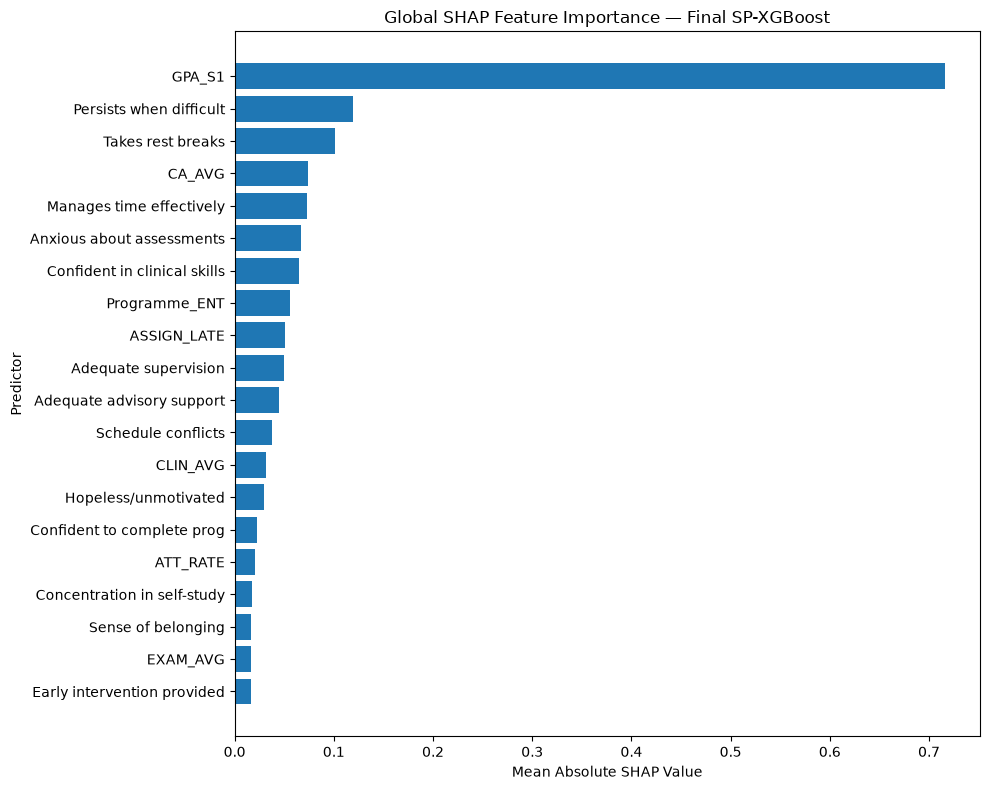


GLOBAL SHAP BAR PLOT VALIDATION
✓ Global SHAP bar plot generated
✓ Top 20 predictors displayed
✓ Figure saved at 300 DPI
✓ Figure path: ..\results\figures\final_sp_xgboost_global_shap_bar_top20.png
✓ Training data used for interpretation
✓ Independent test set was NOT used


In [22]:
#Next: Cell 6 — Global SHAP Bar Plot
#This cell will create and save the global mean absolute SHAP bar plot. 
# It is purely interpretive—no retraining, 
# no feature selection, and no test-set use.
# ======================================================================
# NOTEBOOK 11 — GLOBAL SHAP BAR PLOT
# ======================================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("FINAL SP-XGBOOST — GLOBAL SHAP BAR PLOT")
print("=" * 70)

# ----------------------------------------------------------------------
# SELECT TOP 20 PREDICTORS
# ----------------------------------------------------------------------
TOP_N = 20

top_shap = shap_importance.head(TOP_N).copy()

assert len(top_shap) == TOP_N

# Reverse order so the most important predictor appears at the top
top_shap_plot = top_shap.sort_values(
    by="Mean_Abs_SHAP",
    ascending=True
)

# ----------------------------------------------------------------------
# CREATE FIGURE
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_plot["Feature"],
    top_shap_plot["Mean_Abs_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Predictor")
plt.title(
    "Global SHAP Feature Importance — Final SP-XGBoost"
)

plt.tight_layout()

# ----------------------------------------------------------------------
# SAVE FIGURE
# ----------------------------------------------------------------------
SHAP_BAR_PATH = (
    FIGURE_DIR /
    "final_sp_xgboost_global_shap_bar_top20.png"
)

plt.savefig(
    SHAP_BAR_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
assert SHAP_BAR_PATH.exists()
assert len(top_shap) == 20
assert SHAP_BAR_PATH.stat().st_size > 0

print()
print("=" * 70)
print("GLOBAL SHAP BAR PLOT VALIDATION")
print("=" * 70)

print("✓ Global SHAP bar plot generated")
print("✓ Top 20 predictors displayed")
print("✓ Figure saved at 300 DPI")
print(f"✓ Figure path: {SHAP_BAR_PATH}")
print("✓ Training data used for interpretation")
print("✓ Independent test set was NOT used")

FINAL SP-XGBOOST — SHAP BEESWARM PLOT


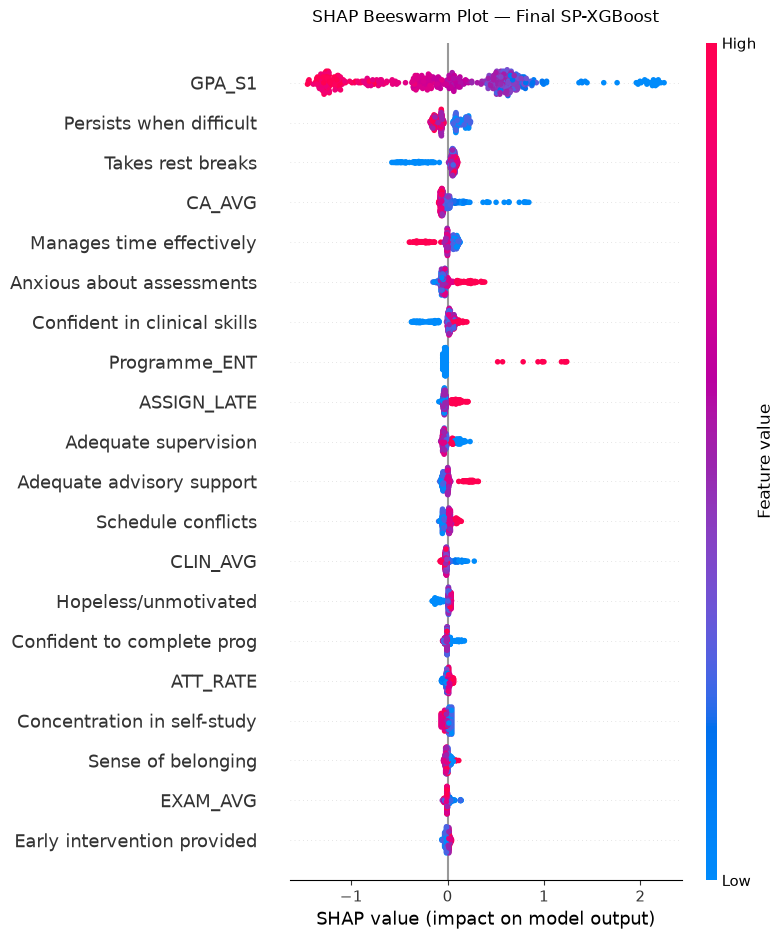


SHAP BEESWARM PLOT VALIDATION
✓ SHAP beeswarm plot generated
✓ Top 20 predictors displayed
✓ SHAP value distribution visualized
✓ Figure saved at 300 DPI
✓ Figure path: ..\results\figures\final_sp_xgboost_shap_beeswarm_top20.png
✓ Training data used for interpretation
✓ Independent test set was NOT used


In [23]:
#Next: Cell 7 — SHAP Beeswarm Plot
#This is the next distinct SHAP analysis we agreed to include. It will show both:
#magnitude of each observation's SHAP contribution, and
#direction of contribution toward the positive class.
# ======================================================================
# NOTEBOOK 11 — SHAP BEESWARM PLOT
# ======================================================================

print("=" * 70)
print("FINAL SP-XGBOOST — SHAP BEESWARM PLOT")
print("=" * 70)

# ----------------------------------------------------------------------
# CREATE BEESWARM PLOT
# ----------------------------------------------------------------------
plt.figure(figsize=(11, 9))

shap.summary_plot(
    shap_values_binary,
    X_train_final,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Beeswarm Plot — Final SP-XGBoost",
    pad=15
)

plt.tight_layout()

# ----------------------------------------------------------------------
# SAVE FIGURE
# ----------------------------------------------------------------------
SHAP_BEESWARM_PATH = (
    FIGURE_DIR /
    "final_sp_xgboost_shap_beeswarm_top20.png"
)

plt.savefig(
    SHAP_BEESWARM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
assert SHAP_BEESWARM_PATH.exists()
assert SHAP_BEESWARM_PATH.stat().st_size > 0

print()
print("=" * 70)
print("SHAP BEESWARM PLOT VALIDATION")
print("=" * 70)

print("✓ SHAP beeswarm plot generated")
print("✓ Top 20 predictors displayed")
print("✓ SHAP value distribution visualized")
print("✓ Figure saved at 300 DPI")
print(f"✓ Figure path: {SHAP_BEESWARM_PATH}")
print("✓ Training data used for interpretation")
print("✓ Independent test set was NOT used")

FINAL SP-XGBOOST — SHAP DEPENDENCE ANALYSIS
Primary predictor: GPA_S1


<Figure size 1000x700 with 0 Axes>

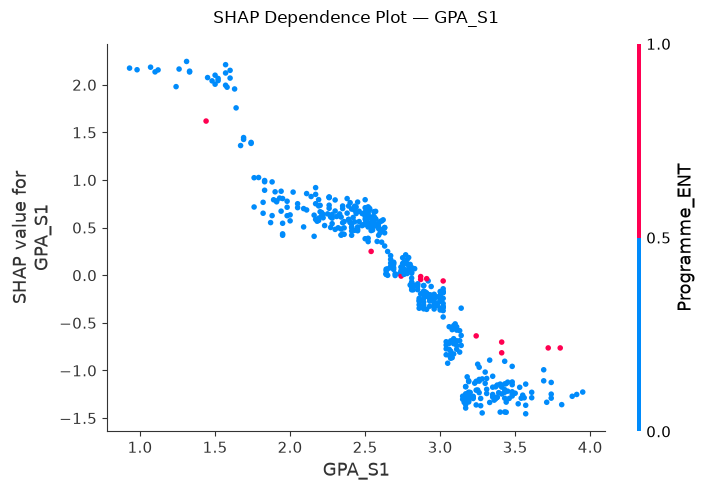


SHAP DEPENDENCE PLOT VALIDATION
✓ GPA_S1 confirmed as a final predictor
✓ SHAP dependence plot generated
✓ SHAP interaction coloring retained
✓ Figure saved at 300 DPI
✓ Figure path: ..\results\figures\final_sp_xgboost_shap_dependence_gpa_s1.png
✓ Training data used for interpretation
✓ Independent test set was NOT used


In [25]:
# ======================================================================
# CELL 8--NOTEBOOK 11 — SHAP DEPENDENCE PLOT: GPA_S1
# ======================================================================

print("=" * 70)
print("FINAL SP-XGBOOST — SHAP DEPENDENCE ANALYSIS")
print("Primary predictor: GPA_S1")
print("=" * 70)

DEPENDENCE_FEATURE = "GPA_S1"

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
assert DEPENDENCE_FEATURE in X_train_final.columns
assert DEPENDENCE_FEATURE in shap_importance["Feature"].values

feature_index = list(X_train_final.columns).index(
    DEPENDENCE_FEATURE
)

assert shap_values_binary.shape == X_train_final.shape

# ----------------------------------------------------------------------
# CREATE DEPENDENCE PLOT
# ----------------------------------------------------------------------
plt.figure(figsize=(10, 7))

shap.dependence_plot(
    DEPENDENCE_FEATURE,
    shap_values_binary,
    X_train_final,
    interaction_index="auto",
    show=False
)

plt.title(
    "SHAP Dependence Plot — GPA_S1",
    pad=15
)

plt.tight_layout()

# ----------------------------------------------------------------------
# SAVE FIGURE
# ----------------------------------------------------------------------
SHAP_DEPENDENCE_GPA_PATH = (
    FIGURE_DIR /
    "final_sp_xgboost_shap_dependence_gpa_s1.png"
)

plt.savefig(
    SHAP_DEPENDENCE_GPA_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------
assert SHAP_DEPENDENCE_GPA_PATH.exists()
assert SHAP_DEPENDENCE_GPA_PATH.stat().st_size > 0

print()
print("=" * 70)
print("SHAP DEPENDENCE PLOT VALIDATION")
print("=" * 70)

print("✓ GPA_S1 confirmed as a final predictor")
print("✓ SHAP dependence plot generated")
print("✓ SHAP interaction coloring retained")
print("✓ Figure saved at 300 DPI")
print(f"✓ Figure path: {SHAP_DEPENDENCE_GPA_PATH}")
print("✓ Training data used for interpretation")
print("✓ Independent test set was NOT used")

In [26]:
# ======================================================================
# CELL 9 -NOTEBOOK 11 — SHAP STATISTICAL ANALYSIS
# ======================================================================

print("=" * 70)
print("FINAL SP-XGBOOST — SHAP STATISTICAL ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

assert "shap_importance" in globals(), \
    "shap_importance is not available. Run the global SHAP importance cell first."

assert "shap_values_binary" in globals(), \
    "shap_values_binary is not available. Calculate SHAP values first."

assert "X_train_final" in globals(), \
    "X_train_final is not available. Load the final training data first."

assert shap_values_binary.shape == X_train_final.shape
assert len(shap_importance) == 49

# ----------------------------------------------------------------------
# BASIC SHAP STATISTICS
# ----------------------------------------------------------------------

shap_abs_values = np.abs(shap_values_binary)

shap_statistics = pd.DataFrame({
    "Statistic": [
        "Number of predictors",
        "Number of training observations",
        "SHAP values per observation",
        "Mean absolute SHAP",
        "Median absolute SHAP",
        "Minimum absolute SHAP",
        "Maximum absolute SHAP",
        "Standard deviation of absolute SHAP"
    ],
    "Value": [
        X_train_final.shape[1],
        X_train_final.shape[0],
        shap_abs_values.size,
        np.mean(shap_abs_values),
        np.median(shap_abs_values),
        np.min(shap_abs_values),
        np.max(shap_abs_values),
        np.std(shap_abs_values)
    ]
})

# ----------------------------------------------------------------------
# FEATURE-LEVEL SHAP STATISTICS
# ----------------------------------------------------------------------

feature_shap_stats = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Mean_SHAP": np.mean(shap_values_binary, axis=0),
    "Mean_Abs_SHAP": np.mean(
        np.abs(shap_values_binary),
        axis=0
    ),
    "Median_SHAP": np.median(shap_values_binary, axis=0),
    "SD_SHAP": np.std(shap_values_binary, axis=0),
    "Min_SHAP": np.min(shap_values_binary, axis=0),
    "Max_SHAP": np.max(shap_values_binary, axis=0)
})

# Absolute importance ranking
feature_shap_stats = (
    feature_shap_stats
    .sort_values(
        by="Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_shap_stats.insert(
    0,
    "Rank",
    np.arange(1, len(feature_shap_stats) + 1)
)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

assert len(feature_shap_stats) == 49
assert feature_shap_stats["Feature"].nunique() == 49

assert np.isfinite(
    feature_shap_stats[
        [
            "Mean_SHAP",
            "Mean_Abs_SHAP",
            "Median_SHAP",
            "SD_SHAP",
            "Min_SHAP",
            "Max_SHAP"
        ]
    ].to_numpy()
).all()

assert (
    feature_shap_stats["Mean_Abs_SHAP"]
    .diff()
    .dropna()
    .le(0)
    .all()
)

# ----------------------------------------------------------------------
# DISPLAY OVERALL STATISTICS
# ----------------------------------------------------------------------

print()
print("OVERALL SHAP STATISTICS")
print("-" * 70)

print(
    shap_statistics.to_string(
        index=False,
        formatters={
            "Value": "{:.6f}".format
        }
    )
)

# ----------------------------------------------------------------------
# DISPLAY TOP 20 FEATURE STATISTICS
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("TOP 20 FEATURES — SHAP STATISTICAL SUMMARY")
print("=" * 70)

print(
    feature_shap_stats.head(20).to_string(
        index=False,
        formatters={
            "Mean_SHAP": "{:.6f}".format,
            "Mean_Abs_SHAP": "{:.6f}".format,
            "Median_SHAP": "{:.6f}".format,
            "SD_SHAP": "{:.6f}".format,
            "Min_SHAP": "{:.6f}".format,
            "Max_SHAP": "{:.6f}".format
        }
    )
)

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("SHAP STATISTICAL ANALYSIS VALIDATION")
print("=" * 70)

print("✓ 49 predictors statistically summarized")
print("✓ 468 training observations represented")
print("✓ Mean SHAP values calculated")
print("✓ Mean absolute SHAP values calculated")
print("✓ Median SHAP values calculated")
print("✓ SHAP standard deviations calculated")
print("✓ Minimum and maximum SHAP values calculated")
print("✓ Feature-level SHAP statistics validated")
print("✓ All statistical values are finite")
print("✓ Features ranked by mean absolute SHAP")
print("✓ Training data used for analysis")
print("✓ Independent test set was NOT used")

FINAL SP-XGBOOST — SHAP STATISTICAL ANALYSIS

OVERALL SHAP STATISTICS
----------------------------------------------------------------------
                          Statistic        Value
               Number of predictors    49.000000
    Number of training observations   468.000000
        SHAP values per observation 22932.000000
                 Mean absolute SHAP     0.037954
               Median absolute SHAP     0.008743
              Minimum absolute SHAP     0.000000
              Maximum absolute SHAP     2.245297
Standard deviation of absolute SHAP     0.131898

TOP 20 FEATURES — SHAP STATISTICAL SUMMARY
 Rank                      Feature Mean_SHAP Mean_Abs_SHAP Median_SHAP  SD_SHAP  Min_SHAP Max_SHAP
    1                       GPA_S1 -0.003705      0.715600    0.037987 0.880210 -1.454531 2.245297
    2      Persists when difficult  0.002185      0.119604   -0.059189 0.129191 -0.183251 0.237160
    3            Takes rest breaks -0.001247      0.100911    0.053189 0.1514

In [27]:
# ======================================================================
# CELL -10_NOTEBOOK 11 — SAVE SHAP STATISTICAL ANALYSIS
# ======================================================================

print("=" * 70)
print("SAVING FINAL SP-XGBOOST SHAP STATISTICAL ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# OUTPUT DIRECTORY
# ----------------------------------------------------------------------

STAT_DIR = os.path.join(
    RESULTS_DIR,
    "statistical_analysis"
)

os.makedirs(STAT_DIR, exist_ok=True)

# ----------------------------------------------------------------------
# SAVE OVERALL SHAP STATISTICS
# ----------------------------------------------------------------------

overall_stats_path = os.path.join(
    STAT_DIR,
    "final_sp_xgboost_shap_overall_statistics.csv"
)

shap_statistics.to_csv(
    overall_stats_path,
    index=False
)

# ----------------------------------------------------------------------
# SAVE COMPLETE FEATURE-LEVEL SHAP STATISTICS
# ----------------------------------------------------------------------

feature_stats_path = os.path.join(
    STAT_DIR,
    "final_sp_xgboost_shap_feature_statistics.csv"
)

feature_shap_stats.to_csv(
    feature_stats_path,
    index=False
)

# ----------------------------------------------------------------------
# SAVE TOP 20 SHAP STATISTICS
# ----------------------------------------------------------------------

top20_stats = feature_shap_stats.head(20).copy()

top20_stats_path = os.path.join(
    STAT_DIR,
    "final_sp_xgboost_shap_top20_statistics.csv"
)

top20_stats.to_csv(
    top20_stats_path,
    index=False
)

# ----------------------------------------------------------------------
# VALIDATE SAVED FILES
# ----------------------------------------------------------------------

assert os.path.isfile(overall_stats_path)
assert os.path.isfile(feature_stats_path)
assert os.path.isfile(top20_stats_path)

# Reload and validate
overall_stats_check = pd.read_csv(
    overall_stats_path
)

feature_stats_check = pd.read_csv(
    feature_stats_path
)

top20_stats_check = pd.read_csv(
    top20_stats_path
)

assert len(overall_stats_check) == len(shap_statistics)
assert len(feature_stats_check) == 49
assert len(top20_stats_check) == 20

assert feature_stats_check["Feature"].nunique() == 49

# ----------------------------------------------------------------------
# DISPLAY RESULTS
# ----------------------------------------------------------------------

print()
print("Saved files:")
print(f"✓ Overall SHAP statistics:")
print(f"  {overall_stats_path}")

print(f"✓ Complete feature-level SHAP statistics:")
print(f"  {feature_stats_path}")

print(f"✓ Top-20 SHAP statistics:")
print(f"  {top20_stats_path}")

print()
print("=" * 70)
print("SHAP STATISTICAL ANALYSIS SAVE VALIDATION")
print("=" * 70)

print("✓ Overall SHAP statistics saved")
print("✓ Complete 49-feature statistical table saved")
print("✓ Top-20 statistical table saved")
print("✓ Saved files successfully reloaded")
print("✓ 49 predictors preserved")
print("✓ 20 top predictors preserved")
print("✓ SHAP statistical-analysis provenance established")

SAVING FINAL SP-XGBOOST SHAP STATISTICAL ANALYSIS

Saved files:
✓ Overall SHAP statistics:
  ..\results\statistical_analysis\final_sp_xgboost_shap_overall_statistics.csv
✓ Complete feature-level SHAP statistics:
  ..\results\statistical_analysis\final_sp_xgboost_shap_feature_statistics.csv
✓ Top-20 SHAP statistics:
  ..\results\statistical_analysis\final_sp_xgboost_shap_top20_statistics.csv

SHAP STATISTICAL ANALYSIS SAVE VALIDATION
✓ Overall SHAP statistics saved
✓ Complete 49-feature statistical table saved
✓ Top-20 statistical table saved
✓ Saved files successfully reloaded
✓ 49 predictors preserved
✓ 20 top predictors preserved
✓ SHAP statistical-analysis provenance established


In [31]:
# ======================================================================
# CELL 11 --NOTEBOOK 11 — FINAL VALIDATION & PROVENANCE
# ======================================================================

print("=" * 70)
print("NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY")
print("AND STATISTICAL ANALYSIS VALIDATION")
print("=" * 70)

# ----------------------------------------------------------------------
# CORE DATA VALIDATION
# ----------------------------------------------------------------------

assert X_train_final.shape == (468, 49)
assert X_test_final.shape == (117, 49)

assert len(y_train_final) == 468
assert len(y_test_final) == 117

print("✓ 468 training observations confirmed")
print("✓ 117 independent test observations confirmed")
print("✓ 49 final predictors confirmed")

# ----------------------------------------------------------------------
# FEATURE ALIGNMENT
# ----------------------------------------------------------------------

training_features = list(X_train_final.columns)
testing_features = list(X_test_final.columns)

assert len(training_features) == 49
assert len(testing_features) == 49

assert training_features == testing_features

print("✓ Training/testing feature counts confirmed")
print("✓ Training/testing feature order matches exactly")

# ----------------------------------------------------------------------
# SHAP VALIDATION
# ----------------------------------------------------------------------

assert shap_values_binary.shape == (468, 49)

assert np.isfinite(
    shap_values_binary
).all()

assert len(shap_importance) == 49
assert shap_importance["Feature"].nunique() == 49

print("✓ Training-set SHAP values validated")
print("✓ 49 predictors ranked by mean absolute SHAP")
print("✓ All SHAP values are finite")

# ----------------------------------------------------------------------
# STATISTICAL ANALYSIS VALIDATION
# ----------------------------------------------------------------------

assert len(feature_shap_stats) == 49
assert feature_shap_stats["Feature"].nunique() == 49

assert len(top20_stats) == 20

print("✓ SHAP statistical analysis validated")
print("✓ Complete 49-feature statistics confirmed")
print("✓ Top-20 statistical summary confirmed")

# ----------------------------------------------------------------------
# REQUIRED FIGURES
# ----------------------------------------------------------------------

global_shap_path = os.path.join(
    RESULTS_DIR,
    "figures",
    "final_sp_xgboost_global_shap_bar_top20.png"
)

beeswarm_path = os.path.join(
    RESULTS_DIR,
    "figures",
    "final_sp_xgboost_shap_beeswarm_top20.png"
)

dependence_path = os.path.join(
    RESULTS_DIR,
    "figures",
    "final_sp_xgboost_shap_dependence_gpa_s1.png"
)

assert os.path.isfile(global_shap_path)
assert os.path.isfile(beeswarm_path)
assert os.path.isfile(dependence_path)

print("✓ Global SHAP bar plot confirmed")
print("✓ SHAP beeswarm plot confirmed")
print("✓ GPA_S1 dependence plot confirmed")

# ----------------------------------------------------------------------
# REQUIRED STATISTICAL ARTIFACTS
# ----------------------------------------------------------------------

overall_stats_path = os.path.join(
    RESULTS_DIR,
    "statistical_analysis",
    "final_sp_xgboost_shap_overall_statistics.csv"
)

feature_stats_path = os.path.join(
    RESULTS_DIR,
    "statistical_analysis",
    "final_sp_xgboost_shap_feature_statistics.csv"
)

top20_stats_path = os.path.join(
    RESULTS_DIR,
    "statistical_analysis",
    "final_sp_xgboost_shap_top20_statistics.csv"
)

assert os.path.isfile(overall_stats_path)
assert os.path.isfile(feature_stats_path)
assert os.path.isfile(top20_stats_path)

print("✓ Overall SHAP statistics confirmed")
print("✓ Complete feature-level statistics confirmed")
print("✓ Top-20 statistics confirmed")

# ----------------------------------------------------------------------
# GPA_S1 VALIDATION
# ----------------------------------------------------------------------

assert "GPA_S1" in X_train_final.columns
assert "GPA_S1" in shap_importance["Feature"].values

print("✓ GPA_S1 confirmed as a final predictor")

# ----------------------------------------------------------------------
# SHAP TRAINING-SET ISOLATION
# ----------------------------------------------------------------------

assert shap_values_binary.shape[0] == X_train_final.shape[0]
assert shap_values_binary.shape[1] == X_train_final.shape[1]

print("✓ SHAP analysis based on 468 training observations")
print("✓ Independent test set was NOT used for SHAP interpretation")

# ----------------------------------------------------------------------
# FINAL PROVENANCE
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL NOTEBOOK 11 VALIDATION")
print("=" * 70)

print("✓ Model explainability artifacts validated")
print("✓ Global SHAP importance validated")
print("✓ SHAP beeswarm visualization validated")
print("✓ GPA_S1 dependence analysis validated")
print("✓ SHAP statistical analysis validated")
print("✓ All required figures confirmed")
print("✓ All required statistical artifacts confirmed")
print("✓ Test-set isolation confirmed")
print("✓ Notebook 11 explainability provenance established")

print()
print("=" * 70)
print("✓ NOTEBOOK 11 — FINAL VALIDATION COMPLETED")
print("=" * 70)

NOTEBOOK 11 — FINAL SP-XGBOOST EXPLAINABILITY
AND STATISTICAL ANALYSIS VALIDATION
✓ 468 training observations confirmed
✓ 117 independent test observations confirmed
✓ 49 final predictors confirmed
✓ Training/testing feature counts confirmed
✓ Training/testing feature order matches exactly
✓ Training-set SHAP values validated
✓ 49 predictors ranked by mean absolute SHAP
✓ All SHAP values are finite
✓ SHAP statistical analysis validated
✓ Complete 49-feature statistics confirmed
✓ Top-20 statistical summary confirmed
✓ Global SHAP bar plot confirmed
✓ SHAP beeswarm plot confirmed
✓ GPA_S1 dependence plot confirmed
✓ Overall SHAP statistics confirmed
✓ Complete feature-level statistics confirmed
✓ Top-20 statistics confirmed
✓ GPA_S1 confirmed as a final predictor
✓ SHAP analysis based on 468 training observations
✓ Independent test set was NOT used for SHAP interpretation

FINAL NOTEBOOK 11 VALIDATION
✓ Model explainability artifacts validated
✓ Global SHAP importance validated
✓ SHAP b